EMPLOYEE PERFORMANCE ANALYTICS SYSTEM

Original Dataset Shape: (52, 9)

First 5 Rows:
  Employee_ID Employee_Name   Department             Position  \
0      EMP001  Aarav Sharma    Marketing  Marketing Executive   
1      EMP002   Aditi Gupta   Operations   Operations Analyst   
2      EMP003   Rohan Mehta      Finance    Financial Analyst   
3      EMP004   Priya Singh    Marketing  Marketing Executive   
4      EMP005   Arjun Verma  Engineering         Data Analyst   

   Performance_Score  Attendance_Percentage  Experience_Years  \
0               96.7                   90.6                 8   
1               98.9                   60.0                10   
2               85.0                   90.1                 8   
3               91.7                   66.9                 4   
4               73.9                   93.2                 1   

   Monthly_Performance Joining_Date  
0                100.0   2025-04-04  
1                 95.1   2025-08-14  
2                 

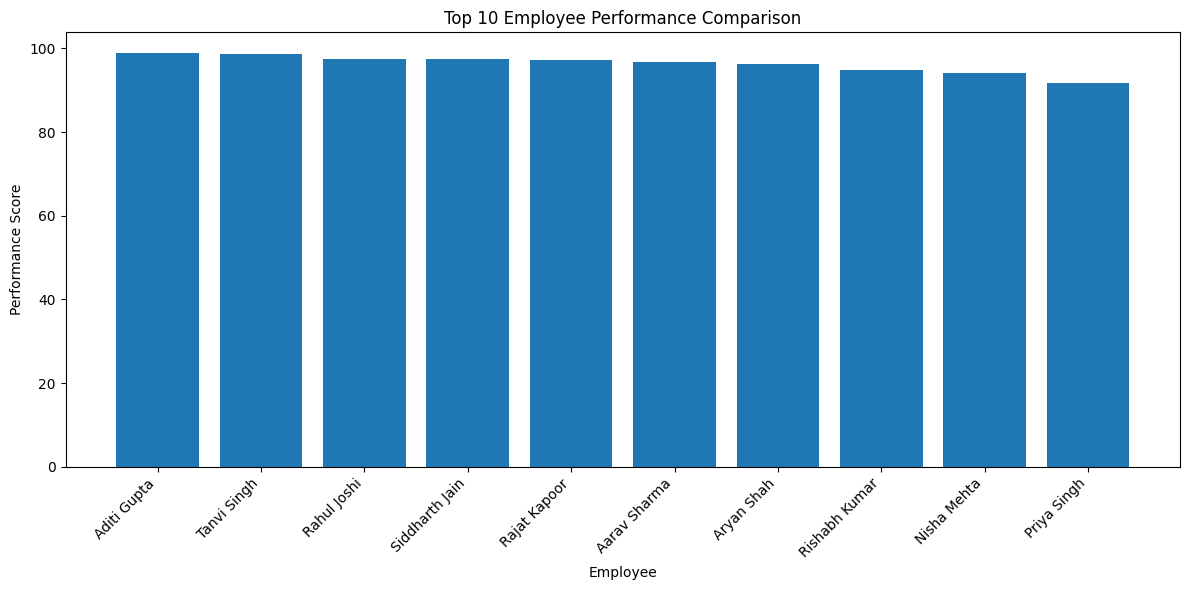

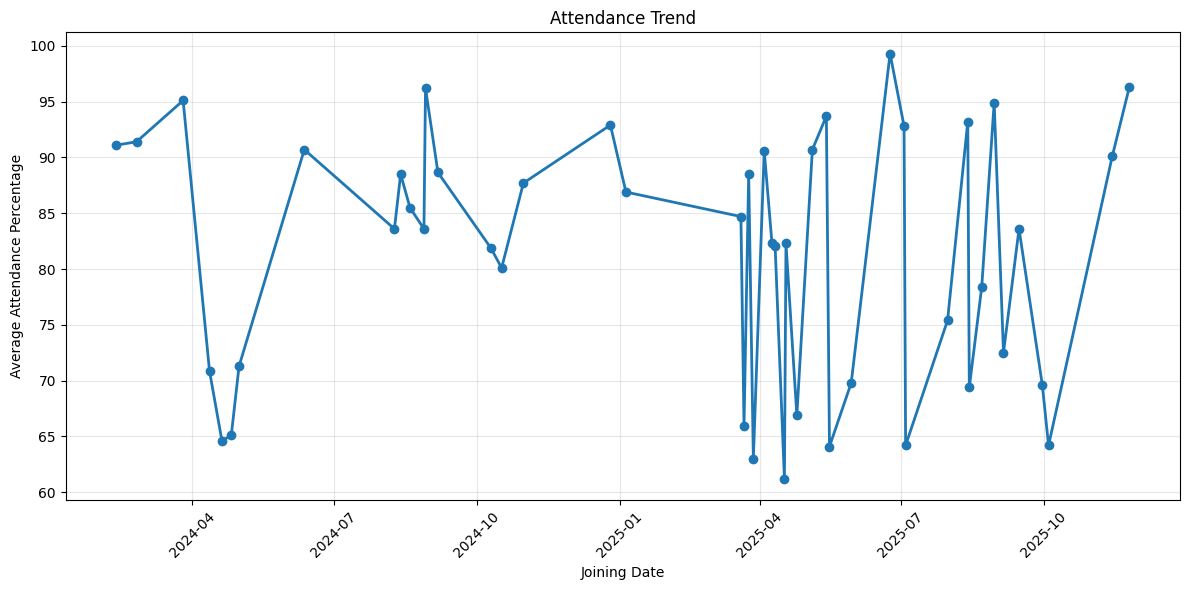

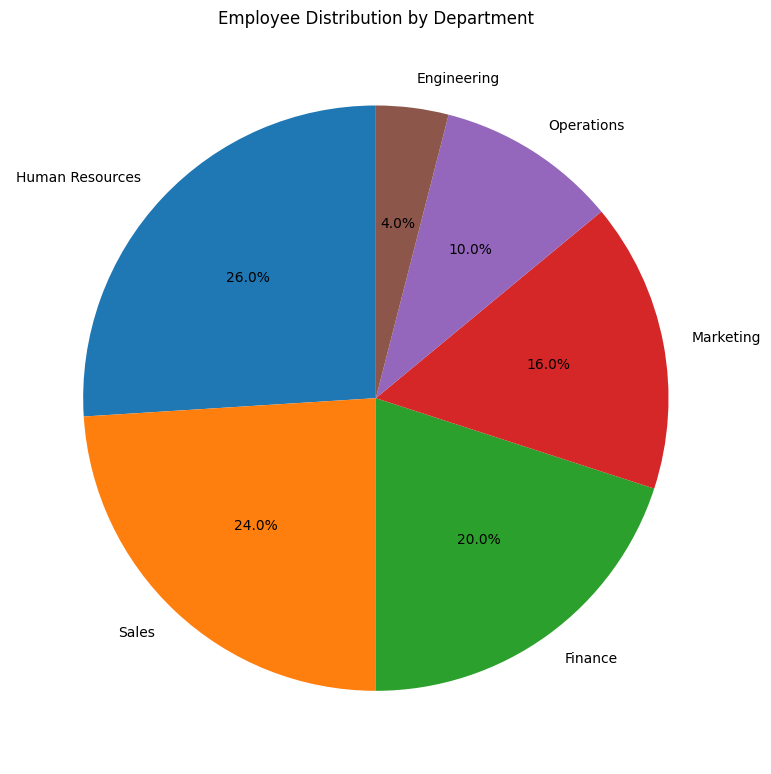


-----------------------------------------------------------------
FINAL REPORT EXPORTED
-----------------------------------------------------------------
File created: final_employee_report.csv

FINAL SUMMARY
Total Employees: 50
Best Performing Department: Marketing (85.71)
Top Performer: Aditi Gupta (98.9)
Employees Below 75% Attendance: 15

Generated Files:
- performance_comparison.png
- attendance_trend.png
- department_distribution.png
- final_employee_report.csv

Project completed successfully!


In [1]:
# Day 23 - Employee Performance Analytics System

import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("employee_performance_dataset.csv")
print("=" * 65)
print("EMPLOYEE PERFORMANCE ANALYTICS SYSTEM")
print("=" * 65)

print("\nOriginal Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\n" + "-" * 65)
print("DATA CLEANING")
print("-" * 65)

print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()
df = df.drop_duplicates()

df["Department"] = df["Department"].fillna(df["Department"].mode()[0])
df["Performance_Score"] = df["Performance_Score"].fillna(
    df["Performance_Score"].median()
)
df["Attendance_Percentage"] = df["Attendance_Percentage"].fillna(
    df["Attendance_Percentage"].median()
)

df["Joining_Date"] = pd.to_datetime(df["Joining_Date"], errors="coerce")

print("\nDuplicate Rows Removed:", duplicate_count)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nCleaned Dataset Shape:", df.shape)


department_performance = (
    df.groupby("Department")["Performance_Score"]
    .mean()
    .sort_values(ascending=False)
)

print("\n" + "-" * 65)
print("DEPARTMENT-WISE AVERAGE PERFORMANCE")
print("-" * 65)
print(department_performance.round(2))


top_10_performers = (
    df.sort_values("Performance_Score", ascending=False)
    .head(10)
)

print("\n" + "-" * 65)
print("TOP 10 PERFORMERS")
print("-" * 65)
print(
    top_10_performers[
        ["Employee_ID", "Employee_Name", "Department", "Performance_Score"]
    ].to_string(index=False)
)



low_attendance = (
    df[df["Attendance_Percentage"] < 75]
    .sort_values("Attendance_Percentage")
)

print("\n" + "-" * 65)
print("EMPLOYEES WITH ATTENDANCE BELOW 75%")
print("-" * 65)

if low_attendance.empty:
    print("No employees found with attendance below 75%.")
else:
    print(
        low_attendance[
            ["Employee_ID", "Employee_Name", "Department",
             "Attendance_Percentage"]
        ].to_string(index=False)
    )

plt.figure(figsize=(12, 6))

plt.bar(
    top_10_performers["Employee_Name"],
    top_10_performers["Performance_Score"]
)

plt.title("Top 10 Employee Performance Comparison")
plt.xlabel("Employee")
plt.ylabel("Performance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("performance_comparison.png", dpi=300)
plt.show()


attendance_trend = (
    df.sort_values("Joining_Date")
    .groupby("Joining_Date")["Attendance_Percentage"]
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    attendance_trend.index,
    attendance_trend.values,
    marker="o",
    linewidth=2
)

plt.title("Attendance Trend")
plt.xlabel("Joining Date")
plt.ylabel("Average Attendance Percentage")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("attendance_trend.png", dpi=300)
plt.show()


department_distribution = df["Department"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    department_distribution.values,
    labels=department_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Employee Distribution by Department")
plt.tight_layout()

plt.savefig("department_distribution.png", dpi=300)
plt.show()



department_avg_map = df.groupby("Department")["Performance_Score"].transform("mean")

df["Department_Avg_Performance"] = department_avg_map
df["Attendance_Status"] = df["Attendance_Percentage"].apply(
    lambda x: "Below 75%" if x < 75 else "75% or Above"
)
df["Performance_Rank"] = df["Performance_Score"].rank(
    ascending=False,
    method="min"
).astype(int)

final_report = df.sort_values(
    ["Performance_Rank", "Employee_Name"]
)

final_report.to_csv("final_employee_report.csv", index=False)

print("\n" + "-" * 65)
print("FINAL REPORT EXPORTED")
print("-" * 65)
print("File created: final_employee_report.csv")


best_department = department_performance.index[0]
best_department_score = department_performance.iloc[0]

top_employee = top_10_performers.iloc[0]

print("\n" + "=" * 65)
print("FINAL SUMMARY")
print("=" * 65)

print(f"Total Employees: {len(df)}")
print(
    f"Best Performing Department: {best_department} "
    f"({best_department_score:.2f})"
)
print(
    f"Top Performer: {top_employee['Employee_Name']} "
    f"({top_employee['Performance_Score']:.1f})"
)
print(f"Employees Below 75% Attendance: {len(low_attendance)}")

print("\nGenerated Files:")
print("- performance_comparison.png")
print("- attendance_trend.png")
print("- department_distribution.png")
print("- final_employee_report.csv")

print("\nProject completed successfully!")
